# Z - scoring diagnostics

Standalone handoff notebook for the 2-class homogenous and 2-class log-normal heterogeneous networks.

This notebook is only meant to do three things:
1. load the saved binary spike tensors and compute observed W/M values
2. build TDMI-matched null distributions
3. convert the observed M values into Z scores and save the resulting tables and plot

The notebook runs from the local files next to it and does **not** require the original project checkout.

Files expected next to this notebook:
- `checkpoints/2class_local_hom.pt`
- `checkpoints/2class_fittedhet_lognorm.pt`
- `spk_tensors/2class_local_hom_spk_tensor.npy`
- `spk_tensors/2class_fittedhet_ln_spk_tensor.npy`

Provenance notes:
- The saved `.npy` arrays are the binary spike tensors from the correct recurrent-layer spike output (`spk_rec`).
- The checkpoints are included for provenance only; the scoring in this notebook uses the saved spike tensors directly.
- `W_M_calculator` and `get_cov` are imported from the bundled `wimfo` repo/package.
- The VAR(1) TDMI-matching null-model block below is adapted from the paper/NuMIT repo path and intentionally kept close to that structure for auditability.

In [1]:
# Basic setup for the standalone handoff folder.
import io
import sys
import math
import hashlib
from pathlib import Path
from contextlib import redirect_stdout

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_lyapunov
from scipy.optimize import root_scalar
from scipy.stats import wishart, norm, rankdata

try:
    NB_DIR = Path(globals()['__vsc_ipynb_file__']).resolve().parent
except Exception:
    NB_DIR = Path(r"C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue")

CHECKPOINT_DIR = NB_DIR / 'checkpoints'
SPK_TENSOR_DIR = NB_DIR / 'spk_tensors'
OUTPUT_DIR = NB_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# Prefer the bundled local copy so this folder can run on another machine as-is.
LOCAL_WIMFO_ROOT = NB_DIR / 'wimfo'
if LOCAL_WIMFO_ROOT.exists() and str(LOCAL_WIMFO_ROOT) not in sys.path:
    sys.path.insert(0, str(LOCAL_WIMFO_ROOT))

# The handoff package only includes these two networks.
TARGETS = {
    '2class_local_hom': {
        'checkpoint': CHECKPOINT_DIR / '2class_local_hom.pt',
        'spike_tensor': SPK_TENSOR_DIR / '2class_local_hom_spk_tensor.npy',
    },
    '2class_fittedhet_ln': {
        'checkpoint': CHECKPOINT_DIR / '2class_fittedhet_lognorm.pt',
        'spike_tensor': SPK_TENSOR_DIR / '2class_fittedhet_ln_spk_tensor.npy',
    },
}

SUBSET_SIZES = [2, 4, 8, 16, 32]
SUBSET_SAMPLE_SIZE = 500
N_NULL = 20
RIDGE = 1e-2
MAX_ATTEMPTS = 900
OBS_LAG = 1

# External repo code: the W/M solver is imported from wimfo.
try:
    from wimfo.W_M_Info import W_M_calculator
    from wimfo.gaussian.double_union_gauss import double_union
    from wimfo.utils.utils_gauss import get_cov, tdmi_from_cov
except Exception:
    import subprocess

    print('Installing wimfo...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wimfo'])
    from wimfo.W_M_Info import W_M_calculator
    from wimfo.gaussian.double_union_gauss import double_union
    from wimfo.utils.utils_gauss import get_cov, tdmi_from_cov

print(f'Notebook dir      : {NB_DIR}')
print(f'Checkpoint dir    : {CHECKPOINT_DIR}')
print(f'Spike tensor dir  : {SPK_TENSOR_DIR}')
print(f'Output dir        : {OUTPUT_DIR}')
print(f'Local wimfo dir   : {LOCAL_WIMFO_ROOT}')
print(f'Subset sizes      : {SUBSET_SIZES}')
print(f'Subset sample size: {SUBSET_SAMPLE_SIZE}')
print(f'N_NULL            : {N_NULL}')

Notebook dir      : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue
Checkpoint dir    : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\checkpoints
Spike tensor dir  : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\spk_tensors
Output dir        : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\outputs
Local wimfo dir   : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\wimfo
Subset sizes      : [2, 4, 8, 16, 32]
Subset sample size: 500
N_NULL            : 20


In [2]:
# Check the packaged files and load the saved binary spike tensors.
# The notebook scores these `.npy` tensors directly. The checkpoints are only here for provenance.
missing = []
for net_key, meta in TARGETS.items():
    ckpt_path = meta['checkpoint']
    spk_path = meta['spike_tensor']
    print(f'{net_key}: checkpoint={ckpt_path.exists()} | spike_tensor={spk_path.exists()}')
    if not ckpt_path.exists():
        missing.append(str(ckpt_path))
    if not spk_path.exists():
        missing.append(str(spk_path))

if missing:
    raise FileNotFoundError('Missing required package files:\n' + '\n'.join(missing))


def load_spike_tensor(path):
    arr = np.load(path)
    if arr.ndim != 2:
        raise ValueError(f'Expected 2D [neurons x time] tensor, got {arr.shape} for {path.name}')
    arr = arr.astype(np.float64, copy=False)
    if not np.all((arr == 0.0) | (arr == 1.0)):
        raise ValueError(f'Spike tensor is not strictly binary for {path.name}')
    return arr


spike_tensors = {}
for net_key, meta in TARGETS.items():
    arr = load_spike_tensor(meta['spike_tensor'])
    spike_tensors[net_key] = arr
    print(f'{net_key:22s} shape={arr.shape} mean_rate={arr.mean():.4f}')

2class_local_hom: checkpoint=True | spike_tensor=True
2class_fittedhet_ln: checkpoint=True | spike_tensor=True
2class_local_hom       shape=(32, 128000) mean_rate=0.0755
2class_fittedhet_ln    shape=(32, 128000) mean_rate=0.0932


In [3]:
# Observed W/M from the bundled spike tensors.
# The preprocessing in this cell is local notebook code.
# `W_M_calculator` and `get_cov` themselves come from the external wimfo repo/package.

def _gc_normalize(data):
    normalized = np.zeros_like(data, dtype=np.float64)
    for row_idx, row in enumerate(data):
        if np.allclose(row, row[0]):
            continue
        ranks = rankdata(row, method='average')
        uniform = np.clip((ranks - 0.5) / len(row), 1e-6, 1.0 - 1e-6)
        normalized[row_idx] = norm.ppf(uniform)
    return normalized


def _inject_jitter(data, eps=1e-6):
    row_std = np.nanstd(data, axis=1)
    flat_rows = np.flatnonzero(row_std <= 1e-12)
    if flat_rows.size == 0:
        return data
    data = data.copy()
    template = np.linspace(-1.0, 1.0, data.shape[1], dtype=np.float64)
    for offset, row_idx in enumerate(flat_rows, start=1):
        data[row_idx] = (eps * offset) * template
    return data


def compute_wm_from_spike_matrix(hidden_data, lag=1, ridge=1e-2):
    # Convert binary spikes to Gaussian scores before sending them into the W/M solver.
    gaussian_data = _gc_normalize(hidden_data.astype(np.float64).copy())
    gaussian_data = np.nan_to_num(gaussian_data, nan=0.0, posinf=0.0, neginf=0.0)
    gaussian_data = _inject_jitter(gaussian_data)

    optimisers = [
        ('Adam', {'atol': 1e-3, 'rtol': 1e-3, 'max_iter': 30000}),
        ('Adam', {'atol': 5e-3, 'rtol': 5e-3, 'max_iter': 60000}),
        ('Newton', None),
    ]
    candidate_lags = sorted({max(int(lag), 1), max(int(lag), 1) * 2, max(int(lag), 1) * 4})
    candidate_strides = [1, 2, 4]
    candidate_ridges = sorted({float(ridge), 5.0 * float(ridge), 1e-1, 2e-1, 5e-1, 1.0})

    # Try the direct data path first.
    for stride in candidate_strides:
        downsampled = gaussian_data[:, ::stride]
        if downsampled.shape[1] <= max(8, 2 * downsampled.shape[0] + 2):
            continue
        for lag_try in candidate_lags:
            for optimiser, options in optimisers:
                try:
                    with io.StringIO() as buf, redirect_stdout(buf):
                        w_bits, m_bits = W_M_calculator(
                            downsampled,
                            t=lag_try,
                            option='data',
                            type='gaussian',
                            unit='bits',
                            verbose=False,
                            optimiser=optimiser,
                            options=options,
                        )
                except Exception:
                    continue
                if np.isfinite(w_bits) and np.isfinite(m_bits):
                    return float(w_bits), float(m_bits), int(downsampled.shape[1])

    # If that fails, build the lagged covariance explicitly and score that distribution.
    last_err = None
    for stride in candidate_strides:
        downsampled = gaussian_data[:, ::stride]
        if downsampled.shape[1] <= max(8, 2 * downsampled.shape[0] + 2):
            continue
        for lag_try in candidate_lags:
            try:
                cov = np.asarray(get_cov(downsampled, t=lag_try), dtype=np.float64)
            except Exception as exc:
                last_err = exc
                continue

            cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)
            cov = 0.5 * (cov + cov.T)
            scale = np.trace(cov) / max(cov.shape[0], 1)
            if not np.isfinite(scale) or scale <= 0.0:
                scale = 1.0
            eye = np.eye(cov.shape[0], dtype=np.float64)

            for ridge_try in candidate_ridges:
                regularized_cov = cov + ridge_try * scale * eye
                try:
                    evals, evecs = np.linalg.eigh(regularized_cov)
                    evals = np.clip(evals, max(scale * 1e-8, 1e-10), None)
                    regularized_cov = (evecs * evals[np.newaxis, :]) @ evecs.T
                    regularized_cov = 0.5 * (regularized_cov + regularized_cov.T)
                except np.linalg.LinAlgError as exc:
                    last_err = exc
                    continue

                for optimiser, options in optimisers:
                    try:
                        with io.StringIO() as buf, redirect_stdout(buf):
                            w_bits, m_bits = W_M_calculator(
                                regularized_cov,
                                option='distr',
                                type='gaussian',
                                unit='bits',
                                verbose=False,
                                optimiser=optimiser,
                                options=options,
                            )
                    except Exception as exc:
                        last_err = exc
                        continue
                    if np.isfinite(w_bits) and np.isfinite(m_bits):
                        return float(w_bits), float(m_bits), int(downsampled.shape[1])

    raise RuntimeError(f'All W/M estimation paths failed. Last error: {last_err}')

In [4]:
# TDMI-matched null model and Z scoring.
# Paper-derived note:
# The VAR(1) helper block below is adapted from the NuMIT / paper notebook path.
# I kept it close to that structure so the null-generation mechanism is easy to audit.

def _sigmoid(x, M=1.0):
    x = np.clip(float(x), -60.0, 60.0)
    return float(M) / (1.0 + np.exp(-x))


def _regularize_cov(cov, ridge=1e-9):
    cov = np.asarray(cov, dtype=np.float64)
    cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)
    cov = 0.5 * (cov + cov.T)
    scale = np.trace(cov) / max(cov.shape[0], 1)
    if (not np.isfinite(scale)) or scale <= 0.0:
        scale = 1.0
    return cov + float(ridge) * scale * np.eye(cov.shape[0], dtype=np.float64)


def _logdet_pd(mat):
    sign, val = np.linalg.slogdet(mat)
    if sign <= 0 or (not np.isfinite(val)):
        raise ValueError('Matrix not positive definite for logdet.')
    return float(val)


def _spectral_radius(A):
    eig = np.linalg.eigvals(A)
    return float(np.max(np.abs(eig)))


def _mi_var1_bits(A, V):
    stationary_cov = solve_discrete_lyapunov(A, V)
    stationary_cov = _regularize_cov(stationary_cov, ridge=1e-12)
    return 0.5 * (_logdet_pd(stationary_cov) - _logdet_pd(V)) / np.log(2.0)


def _lagged_cov_from_var1(A, V):
    stationary_cov = solve_discrete_lyapunov(A, V)
    stationary_cov = _regularize_cov(stationary_cov, ridge=1e-12)
    cross_cov = stationary_cov @ A.T
    return np.block([[stationary_cov, cross_cov], [cross_cov.T, stationary_cov]])


def _numit_var1_from_mi(mi_target_bits, nvar, rng, g_cap=0.9995, tol_bits=1e-3):
    A0 = rng.normal(0.0, 1.0, size=(int(nvar), int(nvar)))
    sr = _spectral_radius(A0)
    if (not np.isfinite(sr)) or sr <= 1e-12:
        return None, None, True, np.nan
    A_unit = A0 / sr

    V = wishart.rvs(df=int(nvar) + 1, scale=np.eye(int(nvar)), random_state=rng)
    V = _regularize_cov(V, ridge=1e-9)

    def mi_error_for_x(x):
        g = float(g_cap) * _sigmoid(x, 1.0)
        A = g * A_unit
        try:
            mi_val = _mi_var1_bits(A, V)
        except Exception:
            return np.nan
        return float(mi_val - float(mi_target_bits))

    search_grid = np.array([-12, -8, -5, -3, -2, -1, 0, 1, 2, 3, 5, 8, 12], dtype=np.float64)
    grid_errors = np.asarray([mi_error_for_x(x) for x in search_grid], dtype=np.float64)

    root_x = None
    near_idx = np.where(np.isfinite(grid_errors) & (np.abs(grid_errors) <= float(tol_bits)))[0]
    if near_idx.size > 0:
        root_x = float(search_grid[int(near_idx[0])])
    else:
        for idx in range(len(search_grid) - 1):
            err_1 = grid_errors[idx]
            err_2 = grid_errors[idx + 1]
            if not (np.isfinite(err_1) and np.isfinite(err_2)):
                continue
            if err_1 * err_2 > 0:
                continue
            try:
                sol = root_scalar(
                    mi_error_for_x,
                    bracket=[float(search_grid[idx]), float(search_grid[idx + 1])],
                    method='brentq',
                    xtol=1e-6,
                    rtol=1e-6,
                    maxiter=100,
                )
            except Exception:
                sol = None
            if sol is not None and sol.converged and np.isfinite(sol.root):
                root_x = float(sol.root)
                break

    if root_x is None:
        return None, None, True, np.nan

    g_star = float(g_cap) * _sigmoid(root_x, 1.0)
    A = g_star * A_unit

    try:
        mi_check = _mi_var1_bits(A, V)
    except Exception:
        return None, None, True, np.nan

    if not np.isfinite(mi_check):
        return None, None, True, np.nan

    allowed_err = max(float(tol_bits), 0.02 * max(float(mi_target_bits), 1e-8))
    if abs(float(mi_check) - float(mi_target_bits)) > allowed_err:
        return None, None, True, float(mi_check)

    return A, V, False, float(mi_check)


def _wm_from_lagged_cov(lagged_cov, ridge=1e-2):
    # Keep the null-model solver bounded so one hard subset does not stall the whole sweep.
    cov = _regularize_cov(lagged_cov, ridge=float(ridge))
    nvar = cov.shape[0] // 2

    if nvar > 15:
        solver_candidates = [
            ('Adam', {'atol': 1e-3, 'rtol': 1e-3, 'max_iter': 400, 'window_size': 21}),
            ('Newton', {'max_iter': 40}),
        ]
    else:
        solver_candidates = [
            ('Newton', {'max_iter': 75}),
            ('Adam', {'atol': 1e-3, 'rtol': 1e-3, 'max_iter': 800, 'window_size': 21}),
        ]

    for optimiser, options in solver_candidates:
        with io.StringIO() as buf, redirect_stdout(buf):
            w_nats = double_union(
                cov,
                nx=nvar,
                optimiser=optimiser,
                options=options,
                verbose=False,
                switch_opt=False,
            )
        if np.isfinite(w_nats):
            tdmi_bits = float(tdmi_from_cov(cov, xdim=nvar))
            w_bits = float(w_nats / np.log(2.0))
            m_bits = float(tdmi_bits - w_bits)
            return w_bits, m_bits

    raise RuntimeError(f'Null W solver failed for nvar={nvar}')


def _stable_seed(net_key, tensor, subset_size):
    token = f'{net_key}|{tensor}|{int(subset_size)}'.encode('utf-8')
    return int(hashlib.sha256(token).hexdigest()[:8], 16)


def build_numit_null_distribution(nvar, tdmi_target_bits, n_null=20, seed=12345, ridge=1e-2, max_attempts=900):
    rng = np.random.default_rng(int(seed))

    null_m = []
    null_w = []
    model_mi_vals = []
    wm_tdmi_vals = []

    attempts = 0
    while len(null_m) < int(n_null) and attempts < int(max_attempts):
        attempts += 1

        # Match the null model to the observed total TDMI first.
        A, V, failed, mi_model = _numit_var1_from_mi(tdmi_target_bits, nvar, rng)
        if failed:
            continue

        try:
            lag_cov = _lagged_cov_from_var1(A, V)
            w_bits, m_bits = _wm_from_lagged_cov(lag_cov, ridge=ridge)
        except Exception:
            continue

        if not (np.isfinite(w_bits) and np.isfinite(m_bits)):
            continue

        null_w.append(float(w_bits))
        null_m.append(float(m_bits))
        model_mi_vals.append(float(mi_model))
        wm_tdmi_vals.append(float(w_bits + m_bits))

    return {
        'null_M_values': null_m,
        'null_W_values': null_w,
        'model_mi_bits': model_mi_vals,
        'wm_tdmi_bits': wm_tdmi_vals,
        'n_null_valid': int(len(null_m)),
        'n_attempts': int(attempts),
    }


def score_observed_vs_null_m(observed_m, null_m_values):
    vals = np.asarray(null_m_values, dtype=np.float64)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return {
            'null_mean': np.nan,
            'null_std': np.nan,
            'z': np.nan,
            'p_upper': np.nan,
            'p_lower': np.nan,
            'p_two_sided': np.nan,
        }

    mu = float(vals.mean())
    sd = float(vals.std(ddof=1)) if vals.size > 1 else np.nan
    z = float((float(observed_m) - mu) / sd) if (np.isfinite(sd) and sd > 1e-12) else np.nan

    ge = np.sum(vals >= float(observed_m))
    le = np.sum(vals <= float(observed_m))
    p_upper = float((1.0 + ge) / (vals.size + 1.0))
    p_lower = float((1.0 + le) / (vals.size + 1.0))
    p_two = float(min(1.0, 2.0 * min(p_upper, p_lower)))

    return {
        'null_mean': mu,
        'null_std': sd,
        'z': z,
        'p_upper': p_upper,
        'p_lower': p_lower,
        'p_two_sided': p_two,
    }

In [6]:
# Observed W/M sweep from fixed-N random subset sampling.
# For each k, sample up to 500 random neuron combinations.
# If fewer than 500 unique combinations exist, use all of them.

def sample_random_subsets(n_neurons, subset_size, sample_size, seed):
    total_possible = math.comb(int(n_neurons), int(subset_size))
    target_size = min(int(sample_size), int(total_possible))
    rng = np.random.default_rng(int(seed))

    sampled = set()
    while len(sampled) < target_size:
        subset = tuple(sorted(rng.choice(n_neurons, size=subset_size, replace=False).tolist()))
        sampled.add(subset)

    return sorted(sampled), total_possible


all_sweeps = {}
observed_rows = []

for net_key, spk in spike_tensors.items():
    nb_hidden = int(spk.shape[0])
    rows = []

    print(f'\n{net_key}')
    for subset_size in SUBSET_SIZES:
        sampled_subsets, total_possible = sample_random_subsets(
            n_neurons=nb_hidden,
            subset_size=subset_size,
            sample_size=SUBSET_SAMPLE_SIZE,
            seed=_stable_seed(net_key, 'subset_sampling', subset_size),
        )

        ok_count = 0
        w_values = []
        m_values = []

        for subset_draw, subset_idx in enumerate(sampled_subsets, start=1):
            try:
                w_bits, m_bits, n_samp = compute_wm_from_spike_matrix(
                    spk[list(subset_idx), :],
                    lag=OBS_LAG,
                    ridge=RIDGE,
                )
                status = 'ok'
                ok_count += 1
                w_values.append(float(w_bits))
                m_values.append(float(m_bits))
            except Exception as exc:
                w_bits, m_bits, n_samp = np.nan, np.nan, 0
                status = f'error: {exc}'

            row = {
                'network': net_key,
                'tensor': 'spk',
                'subset_size': int(subset_size),
                'subset_draw': int(subset_draw),
                'subset_indices': ','.join(map(str, subset_idx)),
                'total_possible_subsets': int(total_possible),
                'observed_W_bits': float(w_bits) if np.isfinite(w_bits) else np.nan,
                'observed_M_bits': float(m_bits) if np.isfinite(m_bits) else np.nan,
                'samples': int(n_samp),
                'status': status,
            }
            rows.append(row)
            observed_rows.append(row.copy())

        print(
            f'  k={subset_size:2d} | sampled {len(sampled_subsets):3d} / {total_possible} subsets | '
            f'ok={ok_count:3d} | '
            f'mean W={np.nanmean(w_values):9.5f} | '
            f'mean M={np.nanmean(m_values):9.5f}'
        )

    all_sweeps[(net_key, 'spk')] = rows

observed_df = pd.DataFrame.from_records(observed_rows)
observed_df = observed_df.sort_values(['network', 'subset_size', 'subset_draw']).reset_index(drop=True)

observed_summary = (
    observed_df.groupby(['network', 'subset_size'], as_index=False)
    .agg(
        sampled_subsets=('subset_draw', 'count'),
        total_possible_subsets=('total_possible_subsets', 'first'),
        observed_W_mean=('observed_W_bits', 'mean'),
        observed_M_mean=('observed_M_bits', 'mean'),
        observed_W_median=('observed_W_bits', 'median'),
        observed_M_median=('observed_M_bits', 'median'),
    )
)

print('\nObserved W/M sweep complete.')
display(observed_summary)

obs_csv = OUTPUT_DIR / 'z_scoring_diagnostics_observed_wm.csv'
observed_df.to_csv(obs_csv, index=False)
print(f'Saved observed W/M CSV: {obs_csv}')


2class_local_hom
  k= 2 | sampled   5 / 496 subsets | ok=  5 | mean W=  1.70528 | mean M= -0.00125
  k= 4 | sampled   5 / 35960 subsets | ok=  5 | mean W=  2.76389 | mean M=  0.03871


C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\wimfo\wimfo\utils\utils_gauss.py:44: RuntimeWarning: invalid value encountered in scalar subtract
  mi = 0.5 * (slogdet(Sx)[1] + slogdet(Sy)[1] - slogdet(cov)[1]) / np.log(2)


  k= 8 | sampled   5 / 10518300 subsets | ok=  5 | mean W=  3.41885 | mean M=  0.31053
  k=16 | sampled   5 / 601080390 subsets | ok=  5 | mean W=  4.50521 | mean M=  0.91078
  k=32 | sampled   1 / 1 subsets | ok=  1 | mean W=  6.04421 | mean M=  2.21800

2class_fittedhet_ln
  k= 2 | sampled   5 / 496 subsets | ok=  5 | mean W=  1.72918 | mean M= -0.00080
  k= 4 | sampled   5 / 35960 subsets | ok=  5 | mean W=  2.83384 | mean M=  0.09486
  k= 8 | sampled   5 / 10518300 subsets | ok=  5 | mean W=  2.85491 | mean M=  0.56581
  k=16 | sampled   5 / 601080390 subsets | ok=  5 | mean W=  4.10453 | mean M=  0.87381
  k=32 | sampled   1 / 1 subsets | ok=  1 | mean W=  5.28928 | mean M=  2.00384

Observed W/M sweep complete.


,network,subset_size,sampled_subsets,total_possible_subsets,observed_W_mean,observed_M_mean,observed_W_median,observed_M_median
0,2class_fittedhet_ln,2,5,496,1.729177,-0.000797,1.573526,-0.001170
1,2class_fittedhet_ln,4,5,35960,2.833845,0.094864,2.981014,-0.001824
2,2class_fittedhet_ln,8,5,10518300,2.854915,0.565811,2.760042,0.572548
3,2class_fittedhet_ln,16,5,601080390,4.104534,0.873812,3.739298,0.801596
4,2class_fittedhet_ln,32,1,1,5.289278,2.003838,5.289278,2.003838
5,2class_local_hom,2,5,496,1.705278,-0.001246,1.013467,-0.000935
6,2class_local_hom,4,5,35960,2.763895,0.038710,3.315492,0.040511
7,2class_local_hom,8,5,10518300,3.418855,0.310531,3.409986,0.190227
8,2class_local_hom,16,5,601080390,4.505208,0.910780,4.457199,0.826061
9,2class_local_hom,32,1,1,6.044208,2.218003,6.044208,2.218003


Saved observed W/M CSV: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\outputs\z_scoring_diagnostics_observed_wm.csv


In [7]:
# Match each observed TDMI (= W + M) with the null model, then Z-score observed M.
# With fixed-N sampling there are many rows per k, so print and display summaries by subset size.
records = []

for (net_key, tensor), rows in sorted(all_sweeps.items(), key=lambda item: (item[0][0], item[0][1])):
    print(f'\nScoring {net_key} / {tensor}')

    for subset_size in sorted({int(row['subset_size']) for row in rows}):
        subset_rows = [row for row in rows if int(row['subset_size']) == subset_size]
        subset_records = []

        for row in sorted(subset_rows, key=lambda item: int(item.get('subset_draw', 0))):
            obs_m = float(row['observed_M_bits'])
            obs_w = float(row['observed_W_bits'])

            if not (np.isfinite(obs_m) and np.isfinite(obs_w)):
                continue

            observed_tdmi = float(obs_m + obs_w)
            null_dist = build_numit_null_distribution(
                nvar=subset_size,
                tdmi_target_bits=observed_tdmi,
                n_null=N_NULL,
                seed=_stable_seed(net_key, tensor, f"{subset_size}_{row['subset_draw']}"),
                ridge=RIDGE,
                max_attempts=MAX_ATTEMPTS,
            )
            score = score_observed_vs_null_m(obs_m, null_dist['null_M_values'])

            model_mi = np.asarray(null_dist['model_mi_bits'], dtype=np.float64)
            wm_tdmi = np.asarray(null_dist['wm_tdmi_bits'], dtype=np.float64)
            record = {
                'network': net_key,
                'tensor': tensor,
                'subset_size': subset_size,
                'subset_draw': int(row['subset_draw']),
                'subset_indices': row['subset_indices'],
                'total_possible_subsets': int(row['total_possible_subsets']),
                'observed_M_bits': obs_m,
                'observed_W_bits': obs_w,
                'observed_TDMI_bits': observed_tdmi,
                'null_M_mean': score['null_mean'],
                'null_M_std': score['null_std'],
                'M_z_tdmi_null': score['z'],
                'M_p_upper_tdmi_null': score['p_upper'],
                'M_p_lower_tdmi_null': score['p_lower'],
                'M_p_two_sided_tdmi_null': score['p_two_sided'],
                'n_null_valid': int(null_dist['n_null_valid']),
                'n_attempts': int(null_dist['n_attempts']),
                'null_model_mi_mean': float(np.nanmean(model_mi)) if model_mi.size else np.nan,
                'null_solver_tdmi_mean': float(np.nanmean(wm_tdmi)) if wm_tdmi.size else np.nan,
                'null_M_values': null_dist['null_M_values'],
                'null_W_values': null_dist['null_W_values'],
                'model_mi_bits': null_dist['model_mi_bits'],
                'wm_tdmi_bits': null_dist['wm_tdmi_bits'],
            }
            records.append(record)
            subset_records.append(record)

        subset_df = pd.DataFrame.from_records(subset_records)
        print(
            f'  k={subset_size:2d} | scored={len(subset_df):3d} | '
            f'mean z={subset_df["M_z_tdmi_null"].mean():8.3f} | '
            f'mean p_upper={subset_df["M_p_upper_tdmi_null"].mean():.4f} | '
            f'mean p_lower={subset_df["M_p_lower_tdmi_null"].mean():.4f}'
        )

scores_df = pd.DataFrame.from_records(records)
scores_df = scores_df.sort_values(['network', 'subset_size', 'subset_draw']).reset_index(drop=True)

score_summary = (
    scores_df.groupby(['network', 'subset_size'], as_index=False)
    .agg(
        scored_subsets=('subset_draw', 'count'),
        total_possible_subsets=('total_possible_subsets', 'first'),
        observed_M_mean=('observed_M_bits', 'mean'),
        observed_TDMI_mean=('observed_TDMI_bits', 'mean'),
        null_M_mean=('null_M_mean', 'mean'),
        null_M_std_mean=('null_M_std', 'mean'),
        M_z_mean=('M_z_tdmi_null', 'mean'),
        M_z_median=('M_z_tdmi_null', 'median'),
        M_p_upper_mean=('M_p_upper_tdmi_null', 'mean'),
        M_p_lower_mean=('M_p_lower_tdmi_null', 'mean'),
        M_p_two_sided_mean=('M_p_two_sided_tdmi_null', 'mean'),
        n_null_valid_mean=('n_null_valid', 'mean'),
    )
)

print('\nScoring complete.')
display(score_summary)

scores_csv = OUTPUT_DIR / 'z_scoring_diagnostics_scores.csv'
scores_df.drop(columns=['null_M_values', 'null_W_values', 'model_mi_bits', 'wm_tdmi_bits']).to_csv(scores_csv, index=False)
print(f'Saved scores CSV: {scores_csv}')


Scoring 2class_fittedhet_ln / spk
  k= 2 | scored=  5 | mean z= -13.842 | mean p_upper=1.0000 | mean p_lower=0.3333
  k= 4 | scored=  5 | mean z=  -5.105 | mean p_upper=1.0000 | mean p_lower=0.3333
  k= 8 | scored=  5 | mean z=-397.538 | mean p_upper=1.0000 | mean p_lower=0.3333
  k=16 | scored=  5 | mean z=  -7.659 | mean p_upper=1.0000 | mean p_lower=0.3333
  k=32 | scored=  1 | mean z=  -6.305 | mean p_upper=1.0000 | mean p_lower=0.3333

Scoring 2class_local_hom / spk
  k= 2 | scored=  5 | mean z=  -2.270 | mean p_upper=1.0000 | mean p_lower=0.3333
  k= 4 | scored=  5 | mean z=  -7.024 | mean p_upper=1.0000 | mean p_lower=0.3333
  k= 8 | scored=  5 | mean z=  -9.604 | mean p_upper=1.0000 | mean p_lower=0.3333
  k=16 | scored=  5 | mean z= -48.237 | mean p_upper=1.0000 | mean p_lower=0.3333
  k=32 | scored=  1 | mean z=  -5.933 | mean p_upper=1.0000 | mean p_lower=0.3333

Scoring complete.


,network,subset_size,scored_subsets,total_possible_subsets,observed_M_mean,observed_TDMI_mean,null_M_mean,null_M_std_mean,M_z_mean,M_z_median,M_p_upper_mean,M_p_lower_mean,M_p_two_sided_mean,n_null_valid_mean
0,2class_fittedhet_ln,2,5,496,-0.000797,1.728379,0.299608,0.129811,-13.842361,-1.724470,1.0,0.333333,0.666667,2.0
1,2class_fittedhet_ln,4,5,35960,0.094864,2.928709,1.115420,0.301270,-5.105318,-4.510991,1.0,0.333333,0.666667,2.0
2,2class_fittedhet_ln,8,5,10518300,0.565811,3.420726,1.876590,0.295256,-397.537726,-9.109828,1.0,0.333333,0.666667,2.0
3,2class_fittedhet_ln,16,5,601080390,0.873812,4.978346,3.111743,0.380146,-7.658764,-6.115588,1.0,0.333333,0.666667,2.0
4,2class_fittedhet_ln,32,1,1,2.003838,7.293117,4.366009,0.374637,-6.305219,-6.305219,1.0,0.333333,0.666667,2.0
5,2class_local_hom,2,5,496,-0.001246,1.704032,0.455167,0.326067,-2.269621,-1.162449,1.0,0.333333,0.666667,2.0
6,2class_local_hom,4,5,35960,0.038710,2.802605,1.074371,0.410040,-7.024272,-3.601104,1.0,0.333333,0.666667,2.0
7,2class_local_hom,8,5,10518300,0.310531,3.729385,2.051153,0.294431,-9.603980,-5.568589,1.0,0.333333,0.666667,2.0
8,2class_local_hom,16,5,601080390,0.910780,5.415988,3.061832,0.563945,-48.236968,-4.789094,1.0,0.333333,0.666667,2.0
9,2class_local_hom,32,1,1,2.218003,8.262210,4.824048,0.439211,-5.933465,-5.933465,1.0,0.333333,0.666667,2.0


Saved scores CSV: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\outputs\z_scoring_diagnostics_scores.csv


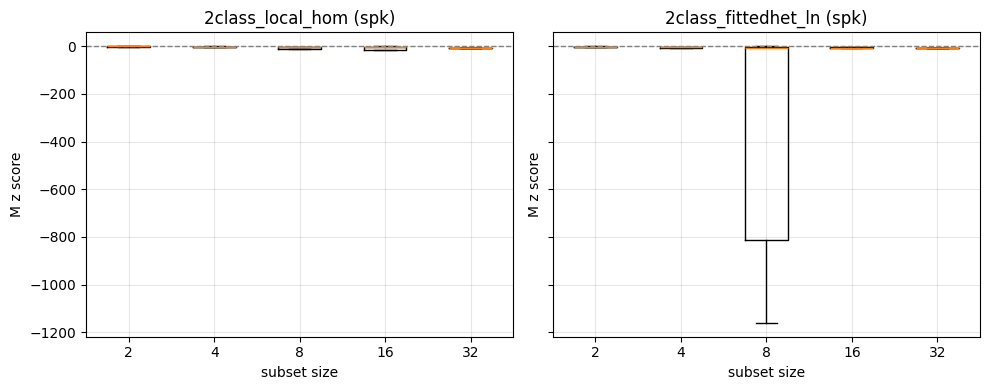

Saved plot: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\outputs\z_scoring_diagnostics_zscores.png


In [8]:
# Box plots summarise the sampled Z-score distributions for each subset size.
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, net_key in zip(axes, ['2class_local_hom', '2class_fittedhet_ln']):
    sub = scores_df[scores_df['network'] == net_key].sort_values(['subset_size', 'subset_draw'])
    subset_sizes = sorted(sub['subset_size'].unique())
    box_data = [
        sub.loc[sub['subset_size'] == subset_size, 'M_z_tdmi_null'].dropna().to_numpy()
        for subset_size in subset_sizes
    ]

    ax.boxplot(box_data, tick_labels=[str(k) for k in subset_sizes], showfliers=False)
    ax.axhline(0.0, color='gray', linewidth=1, linestyle='--')
    ax.set_title(net_key + ' (spk)')
    ax.set_xlabel('subset size')
    ax.set_ylabel('M z score')
    ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = OUTPUT_DIR / 'z_scoring_diagnostics_zscores.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved plot: {plot_path}')